<a href="https://colab.research.google.com/github/rodrigorissettoterra/SENAI_Concepcao_e_Design_de_ML/blob/main/Previs%C3%A3o_pre%C3%A7os_im%C3%B3veis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATIVIDADE - Previsão de preços de imóveis

Dataset: California Housing (Scikit-Learn)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Carregar dataset

In [2]:
dados = fetch_california_housing()

X = dados.data
y = dados.target

feature_names = dados.feature_names

# Criar DataFrame para análise
df = pd.DataFrame(X, columns=feature_names)
df["Preco"] = y

print("Shape da base:", df.shape)

print("\nPrimeiras linhas:")
print(df.head())

Shape da base: (20640, 9)

Primeiras linhas:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Preco  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


Análise exploratória

In [3]:
print("\nDescrição estatística:")
print(df.describe())


Descrição estatística:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Preco  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min     

Matriz de correlação

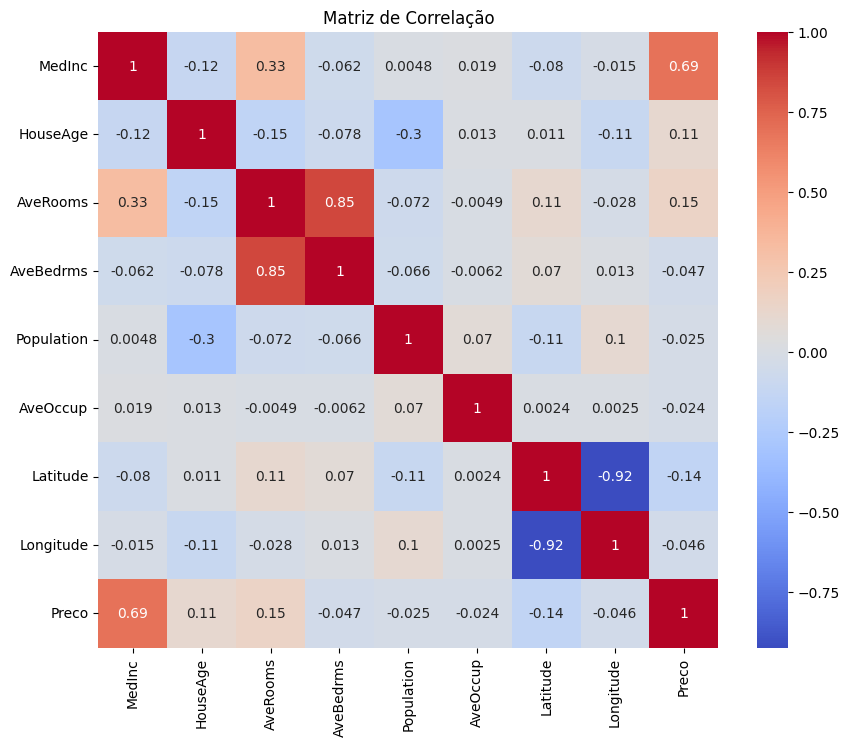

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

Separar variáveis

In [5]:
X = df.drop("Preco", axis=1)
y = df["Preco"]

Divisão treino/teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTreino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (16512, 8)
Teste: (4128, 8)


Treinar modelo de regressão linear

In [7]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

Predição

In [8]:
y_pred = modelo.predict(X_test)

Avaliação do modelo

In [9]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R²: 0.5757877060324508


Comparação valores reais vs previstos

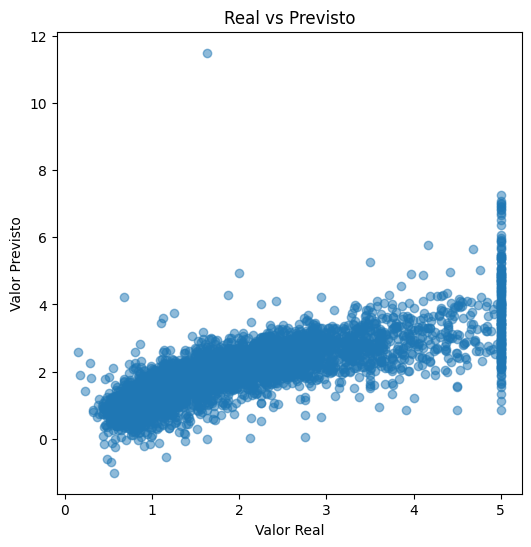

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Real vs Previsto")
plt.show()

Importância das variáveis (coeficientes)

In [11]:
coef_df = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo.coef_
}).sort_values(by="Coeficiente", ascending=False)

print("\nImportância das variáveis:")
print(coef_df)


Importância das variáveis:
     Variavel  Coeficiente
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


Exemplo de previsão

In [12]:
exemplo = X_test.iloc[0].values.reshape(1, -1)
previsao = modelo.predict(exemplo)[0]

print("\nExemplo de previsão:")
print("Valor real:", y_test.iloc[0])
print("Valor previsto:", previsao)


Exemplo de previsão:
Valor real: 0.477
Valor previsto: 0.7191228416019086


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
